In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import re

In [3]:
WD = "~/Documents/GitHub/glucoring/"
round = 1


min_conc = pd.read_csv(WD+f'src/data/17-june/0{round}/1mmolphantom.csv')
max_conc = pd.read_csv(WD+f'src/data/17-june/0{round}/10mmolphantom.csv')
none_conc = pd.read_csv(WD+f'src/data/17-june/0{round}/nothingphantom.csv')
air = pd.read_csv(WD+f'src/data/17-june/0{round}/air.csv')

In [4]:
# 19 june
datasets = {
    '2mmol phantom 1': pd.read_csv(WD+f'src/data/19-june/0{round}/2mmolphantom(1).csv'),
    '2mmol phantom 2': pd.read_csv(WD+f'src/data/19-june/0{round}/2mmolphantom(2).csv'),
    '2mmol phantom 3': pd.read_csv(WD+f'src/data/19-june/0{round}/2mmolphantom(3).csv'),
    '5mmol phantom 1': pd.read_csv(WD+f'src/data/19-june/0{round}/5mmolphantom(1).csv'),
    '5mmol phantom 2': pd.read_csv(WD+f'src/data/19-june/0{round}/5mmolphantom(2).csv'),
    '5mmol phantom 3': pd.read_csv(WD+f'src/data/19-june/0{round}/5mmolphantom(3).csv'),
    '10mmol phantom 1': pd.read_csv(WD+f'src/data/19-june/0{round}/9.5mmolphantom(1).csv'),
    '10mmol phantom 2': pd.read_csv(WD+f'src/data/19-june/0{round}/9.5mmolphantom(2).csv'),
    '10mmol phantom 3': pd.read_csv(WD+f'src/data/19-june/0{round}/9.5mmolphantom(3).csv'),
}

datasets['10mmol phantom 1']

,Frequency(Hz),Return Loss(dB),Phase(deg),Rs,SWR,Xs,|Z|,Theta
0,1000000,-0.94,-16.76,112.0,18.53,-298.4,318.8,-69.4
1,4373452,-1.41,-29.14,58.3,12.35,-174.2,183.7,-71.5
2,7746904,-1.81,-41.66,38.2,9.65,-121.0,126.9,-72.5
3,11120356,-2.02,-55.19,25.7,8.64,-90.0,93.6,-74.1
4,14493808,-2.09,-69.64,17.8,8.37,-68.8,71.1,-75.5
...,...,...,...,...,...,...,...,...
885,2986505020,-9.84,149.97,27.0,1.95,9.7,28.7,19.8
886,2989878472,-9.44,144.72,26.6,2.02,11.7,29.1,23.7
887,2993251924,-9.94,140.88,28.2,1.93,12.6,30.9,24.1
888,2996625376,-10.06,136.14,29.0,1.92,14.0,32.3,25.8



2mmol (averaged across 3 phantoms)
mean     : -4.494315
std      : 3.273929
min      : -21.373333
variance : 10.718612
skewness : -1.560220

5mmol (averaged across 3 phantoms)
mean     : -4.877397
std      : 3.452519
min      : -27.726667
variance : 11.919884
skewness : -1.648153

10mmol (averaged across 3 phantoms)
mean     : -4.571049
std      : 3.246255
min      : -21.613333
variance : 10.538173
skewness : -1.508485


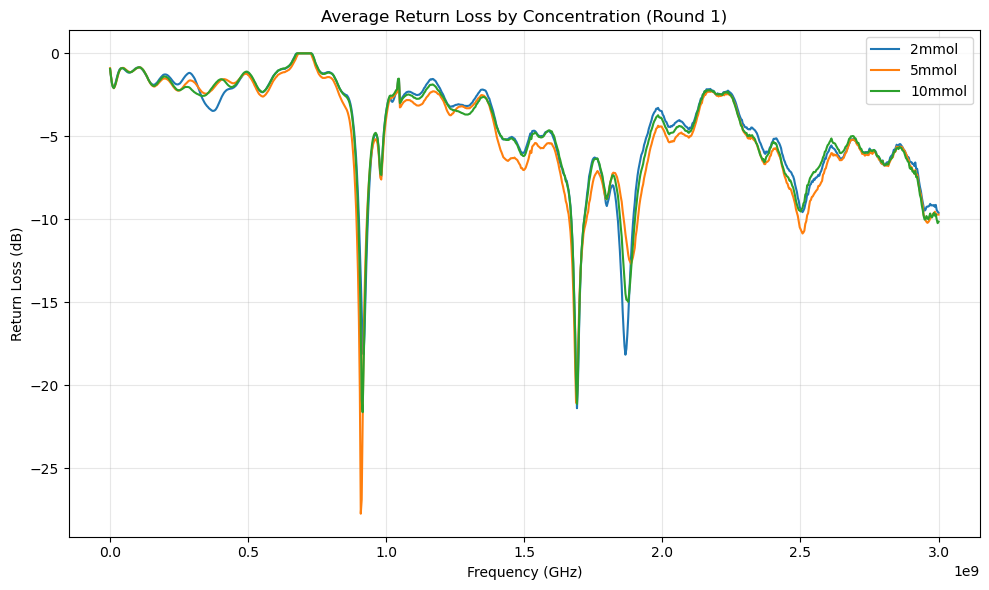

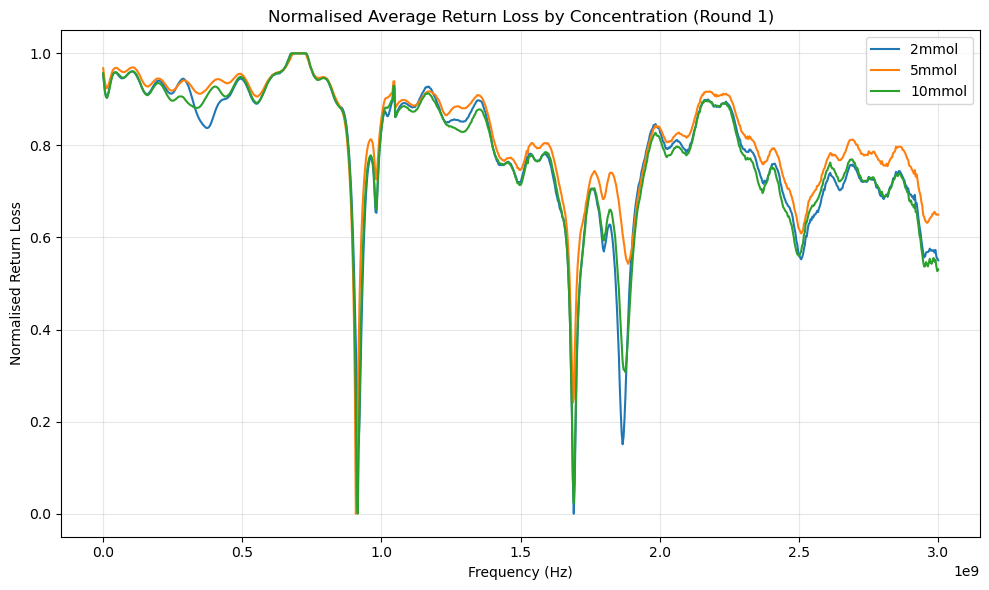


2mmol (normalised, averaged across 3 phantoms)
mean     : 0.789723
std      : 0.153178
min      : 0.000000
variance : 0.023464
skewness : -1.560220

5mmol (normalised, averaged across 3 phantoms)
mean     : 0.824090
std      : 0.124520
min      : 0.000000
variance : 0.015505
skewness : -1.648153

10mmol (normalised, averaged across 3 phantoms)
mean     : 0.788508
std      : 0.150197
min      : 0.000000
variance : 0.022559
skewness : -1.508485


In [5]:
# Group datasets by concentration
concentrations = {
    '2mmol':  [datasets['2mmol phantom 1'],  datasets['2mmol phantom 2'],  datasets['2mmol phantom 3']],
    '5mmol':  [datasets['5mmol phantom 1'],  datasets['5mmol phantom 2'],  datasets['5mmol phantom 3']],
    '10mmol': [datasets['10mmol phantom 1'], datasets['10mmol phantom 2'], datasets['10mmol phantom 3']],
}

col = 'Return Loss(dB)'
freq_col = 'Frequency(Hz)'

# Compute per-concentration averages
averaged = {}
frequencies = {}
for conc, dfs in concentrations.items():
    combined = pd.concat([df[col].reset_index(drop=True) for df in dfs], axis=1)
    averaged[conc] = combined.mean(axis=1)
    frequencies[conc] = dfs[0][freq_col].reset_index(drop=True)  # same across phantoms

# Print stats for each concentration
stats_col = 'Return Loss(dB)'

for conc, avg_series in averaged.items():
    print(f"\n{'='*50}")
    print(f"{conc} (averaged across 3 phantoms)")
    print(f"{'='*50}")
    print(f"mean     : {avg_series.mean():.6f}")
    print(f"std      : {avg_series.std():.6f}")
    print(f"min      : {avg_series.min():.6f}")
    print(f"variance : {avg_series.var():.6f}")
    print(f"skewness : {avg_series.skew():.6f}")


# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for conc, avg_series in averaged.items():
    ax.plot(frequencies[conc], avg_series.values, label=conc)

ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Return Loss (dB)')
ax.set_title(f'Average Return Loss by Concentration (Round {round})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Normalise each averaged series to [0, 1]
scaler = MinMaxScaler()

normalised = {}
for conc, avg_series in averaged.items():
    normalised[conc] = pd.Series(
        scaler.fit_transform(avg_series.values.reshape(-1, 1)).flatten(),
        index=avg_series.index
    )

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for conc, norm_series in normalised.items():
    ax.plot(frequencies[conc], norm_series.values, label=conc)

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Normalised Return Loss')
ax.set_title(f'Normalised Average Return Loss by Concentration (Round {round})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print stats on normalised data
for conc, norm_series in normalised.items():
    print(f"\n{'='*50}")
    print(f"{conc} (normalised, averaged across 3 phantoms)")
    print(f"{'='*50}")
    print(f"mean     : {norm_series.mean():.6f}")
    print(f"std      : {norm_series.std():.6f}")
    print(f"min      : {norm_series.min():.6f}")
    print(f"variance : {norm_series.var():.6f}")
    print(f"skewness : {norm_series.skew():.6f}")


2mmol (averaged across 3 phantoms)
mean     : 5.109367
std      : 108.326717
min      : -178.560000
variance : 11734.677642
skewness : -0.091316

5mmol (averaged across 3 phantoms)
mean     : 9.603963
std      : 107.653952
min      : -179.346667
variance : 11589.373359
skewness : -0.135489

10mmol (averaged across 3 phantoms)
mean     : 8.939120
std      : 107.516100
min      : -179.453333
variance : 11559.711813
skewness : -0.127166


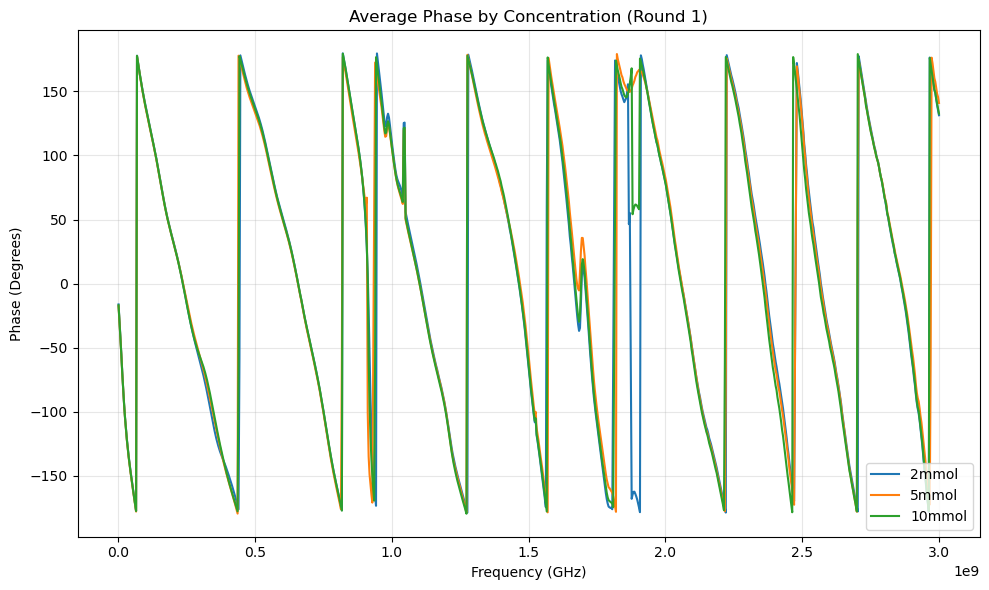

In [6]:
# Group datasets by concentration
concentrations = {
    '2mmol':  [datasets['2mmol phantom 1'],  datasets['2mmol phantom 2'],  datasets['2mmol phantom 3']],
    '5mmol':  [datasets['5mmol phantom 1'],  datasets['5mmol phantom 2'],  datasets['5mmol phantom 3']],
    '10mmol': [datasets['10mmol phantom 1'], datasets['10mmol phantom 2'], datasets['10mmol phantom 3']],
}

col = 'Phase(deg)'
freq_col = 'Frequency(Hz)'

# Compute per-concentration averages
averaged = {}
frequencies = {}
for conc, dfs in concentrations.items():
    combined = pd.concat([df[col].reset_index(drop=True) for df in dfs], axis=1)
    averaged[conc] = combined.mean(axis=1)
    frequencies[conc] = dfs[0][freq_col].reset_index(drop=True)  # same across phantoms


for conc, avg_series in averaged.items():
    print(f"\n{'='*50}")
    print(f"{conc} (averaged across 3 phantoms)")
    print(f"{'='*50}")
    print(f"mean     : {avg_series.mean():.6f}")
    print(f"std      : {avg_series.std():.6f}")
    print(f"min      : {avg_series.min():.6f}")
    print(f"variance : {avg_series.var():.6f}")
    print(f"skewness : {avg_series.skew():.6f}")


# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for conc, avg_series in averaged.items():
    ax.plot(frequencies[conc], avg_series.values, label=conc)

ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Phase (Degrees)')
ax.set_title(f'Average Phase by Concentration (Round {round})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# 17 june
datasets = {
    '1 mmol phantom': min_conc,
    '10 mmol phantom': max_conc,
    'air': air,
    'None phantom': none_conc
}

cols = ['Return Loss(dB)']

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")

    for col in cols:
        print(f"\n{col}")
        print(f"count    : {df[col].count()}")
        print(f"mean     : {df[col].mean()}")
        print(f"std      : {df[col].std()}")
        print(f"min      : {df[col].min()}")
        print(f"25%      : {df[col].quantile(0.25)}")
        print(f"median   : {df[col].median()}")
        print(f"75%      : {df[col].quantile(0.75)}")
        print(f"max      : {df[col].max()}")
        print(f"variance : {df[col].var()}")
        print(f"skewness : {df[col].skew()}")

NameError: name 'min_conc' is not defined

In [54]:
DIR = '/Users/aryan/Documents/Github/glucoring/' + f'src/data/24-june/'

data = {}

for folder in os.listdir(DIR):
    if folder.startswith('.'):
        continue  
    else:
        folder_path = os.path.join(DIR, folder)
        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                if file.endswith('.csv'):
                    file_path = os.path.join(folder_path, file)
                    data[folder+'_'+file] = pd.read_csv(file_path)

data.keys()

dict_keys(['jenny-11.4_VNA_260624_203026.csv', 'jenny-11.4_VNA_260624_203038.csv', 'jenny-11.4_VNA_260624_203058.csv', 'aryan-5.8_VNA_260624_204328.csv', 'aryan-5.8_VNA_260624_204317.csv', 'aryan-5.8_VNA_260624_204343.csv', 'aryan-5.9_VNA_260624_190817.csv', 'aryan-5.9_VNA_260624_190844.csv', 'aryan-5.9_VNA_260624_190854.csv', 'jenny-8.5_VNA_260624_195658.csv', 'jenny-8.5_VNA_260624_195648.csv', 'jenny-8.5_VNA_260624_195708.csv', 'jenny-5.0_VNA_260624_190457.csv', 'jenny-5.0_VNA_260624_190527.csv', 'jenny-5.0_VNA_260624_190516.csv', 'aryan-7.7_VNA_260624_200004.csv', 'aryan-7.7_VNA_260624_195954.csv', 'aryan-7.7_VNA_260624_195945.csv'])


──────────────────────────────────────────────────────────────────────
FOLDER                  RL Min    RL Max   RL Mean    RL Std  Min @ (MHz)
──────────────────────────────────────────────────────────────────────
aryan-5.8               -18.77      0.00     -5.99      2.88      1689.06
aryan-5.9               -14.94      0.00     -5.50      2.68      1689.06
aryan-7.7               -17.69      0.00     -6.29      3.11      1692.05
jenny-11.4              -16.93      0.00     -5.98      2.70      1689.06
jenny-5.0               -16.73      0.00     -6.01      2.42      1689.06
jenny-8.5               -15.71      0.00     -5.97      2.44      1689.06
──────────────────────────────────────────────────────────────────────



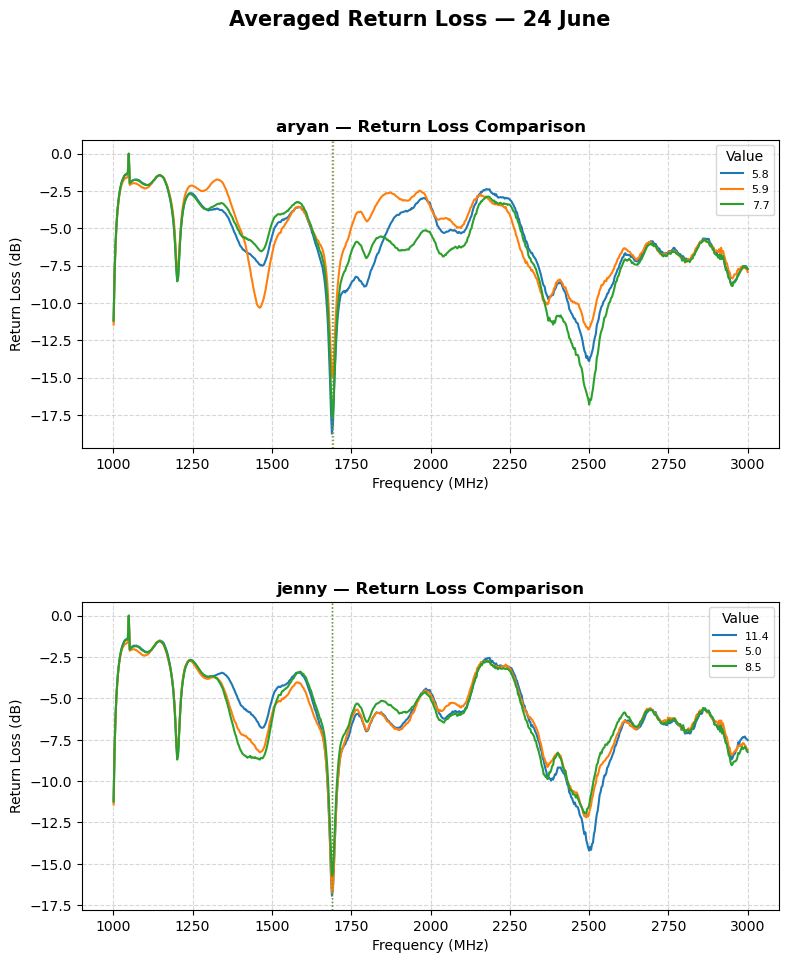

Plot saved to return_loss_summary.png


In [59]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

DIR = '/Users/aryan/Documents/Github/glucoring/' + 'src/data/24-june/'
COLS = ['Frequency(Hz)', 'Return Loss(dB)']

FREQ_MIN_MHZ = 1000
FREQ_MAX_MHZ = 3000

# ── 1. Load data ──────────────────────────────────────────────────────────────
data = {}
for folder in os.listdir(DIR):
    if folder.startswith('.'):
        continue
    folder_path = os.path.join(DIR, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith('.csv'):
                file_path = os.path.join(folder_path, file)
                data[folder + '_' + file] = pd.read_csv(file_path)

# ── 2. Average 3 files per folder ─────────────────────────────────────────────
folders = sorted({key.split('_')[0] for key in data})
averaged = {}

for folder in folders:
    group = [df[COLS] for key, df in data.items() if key.startswith(folder + '_')]
    if len(group) != 3:
        print(f"⚠️  '{folder}' has {len(group)} file(s), expected 3 — skipping.")
        continue
    averaged[folder] = pd.concat(group).groupby(level=0).mean().reset_index(drop=True)
    averaged[folder]['Frequency(Hz)'] = group[0]['Frequency(Hz)'].values

# ── 3. Filter frequency range ─────────────────────────────────────────────────
for folder in averaged:
    df   = averaged[folder]
    mask = (df['Frequency(Hz)'] / 1e6 >= FREQ_MIN_MHZ) & \
           (df['Frequency(Hz)'] / 1e6 <= FREQ_MAX_MHZ)
    averaged[folder] = df[mask].reset_index(drop=True)

# ── 4. Group folders by base name (strip trailing digits + decimals) ───────────
groups = {}
for folder in averaged:
    base = re.sub(r'[\s_-]*[\d.]+$', '', folder)  # 'jenny-8.5' → 'jenny'
    groups.setdefault(base, []).append(folder)

# ── 5. Statistics ─────────────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print(f"{'FOLDER':<20} {'RL Min':>9} {'RL Max':>9} {'RL Mean':>9} {'RL Std':>9} {'Min @ (MHz)':>12}")
print(f"{'─'*70}")

for folder, df in averaged.items():
    rl       = df['Return Loss(dB)']
    freq_mhz = df['Frequency(Hz)'] / 1e6
    min_idx  = rl.idxmin()
    print(f"{folder:<20} {rl.min():>9.2f} {rl.max():>9.2f} {rl.mean():>9.2f} {rl.std():>9.2f} {freq_mhz[min_idx]:>12.2f}")

print(f"{'─'*70}\n")

# ── 6. Plot — one subplot per base group, all variants overlaid ───────────────
n      = len(groups)
fig    = plt.figure(figsize=(9, 5 * n))
gs     = gridspec.GridSpec(n, 1, figure=fig, hspace=0.5)
colors = plt.cm.tab10.colors

for i, (base, members) in enumerate(sorted(groups.items())):
    ax = fig.add_subplot(gs[i, 0])

    for j, folder in enumerate(sorted(members)):
        df       = averaged[folder]
        freq_mhz = df['Frequency(Hz)'] / 1e6
        rl       = df['Return Loss(dB)']
        color    = colors[j % len(colors)]
        min_idx  = rl.idxmin()
        label    = re.search(r'[\d.]+$', folder).group()

        ax.plot(freq_mhz, rl, color=color, linewidth=1.5, label=label)
        ax.axvline(freq_mhz[min_idx], color=color, linestyle=':', linewidth=1.0,
                   alpha=0.7)

    ax.set_title(f'{base} — Return Loss Comparison', fontweight='bold')
    ax.set_xlabel('Frequency (MHz)')
    ax.set_ylabel('Return Loss (dB)')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title='Value', fontsize=8)

plt.suptitle('Averaged Return Loss — 24 June', fontsize=15, fontweight='bold', y=1.01)
plt.savefig(os.path.join(DIR, 'return_loss_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to return_loss_summary.png")


──────────────────────────────────────────────────────────────────────
FOLDER                  RL Min    RL Max   RL Mean    RL Std  Min @ (MHz)
──────────────────────────────────────────────────────────────────────
aryan-0                 -13.39      0.00     -5.54      2.59      2500.17
aryan-4.8               -16.29     -0.09     -5.34      3.04      1478.57
aryan-7.1               -15.48     -0.04     -5.77      2.33      1691.10
jenny-5.4               -14.76     -0.19     -5.59      2.86      1448.21
jenny-8.5               -20.97     -0.05     -5.48      3.32      1461.70
jenny-9.7               -14.99      0.00     -5.17      2.80      1461.59
──────────────────────────────────────────────────────────────────────



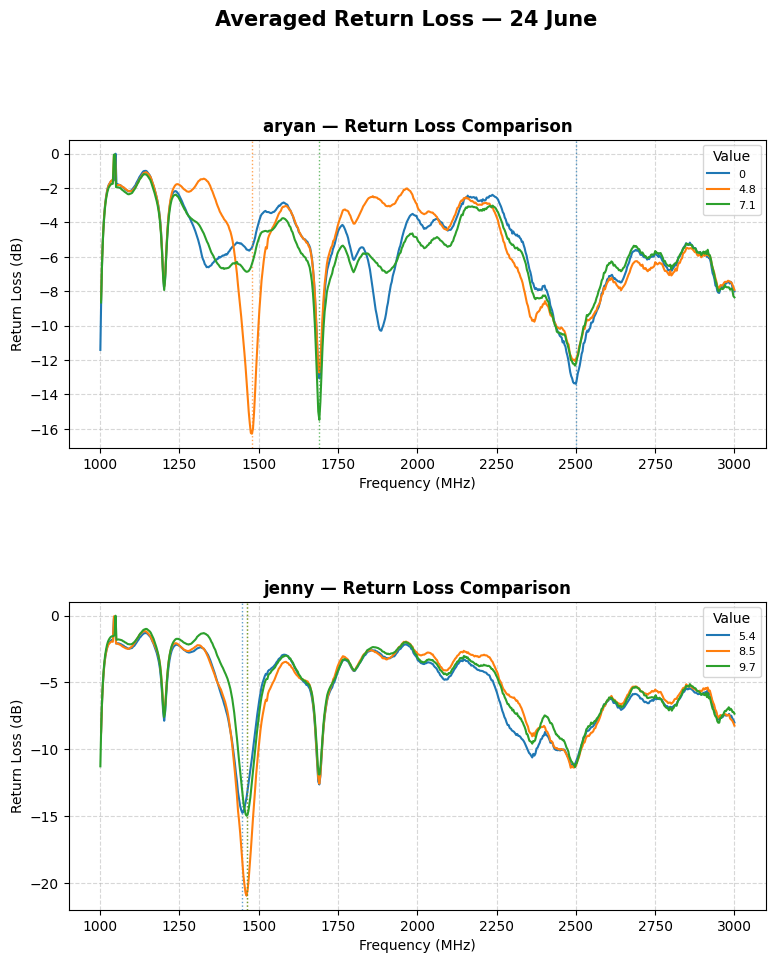

Plot saved to return_loss_summary.png


In [7]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

DIR = '/Users/jenny/Documents/Github/glucoring/' + 'src/data/25-june/'
COLS = ['Frequency(Hz)', 'Return Loss(dB)']

FREQ_MIN_MHZ = 1000
FREQ_MAX_MHZ = 3000

# ── 1. Load data ──────────────────────────────────────────────────────────────
data = {}
for folder in os.listdir(DIR):
    if folder.startswith('.'):
        continue
    folder_path = os.path.join(DIR, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith('.csv'):
                file_path = os.path.join(folder_path, file)
                data[folder + '_' + file] = pd.read_csv(file_path)

# ── 2. Average 3 files per folder ─────────────────────────────────────────────
folders = sorted({key.split('_')[0] for key in data})
averaged = {}

for folder in folders:
    group = [df[COLS] for key, df in data.items() if key.startswith(folder + '_')]
    if len(group) != 3:
        print(f"⚠️  '{folder}' has {len(group)} file(s), expected 3 — skipping.")
        continue
    averaged[folder] = pd.concat(group).groupby(level=0).mean().reset_index(drop=True)
    averaged[folder]['Frequency(Hz)'] = group[0]['Frequency(Hz)'].values

# ── 3. Filter frequency range ─────────────────────────────────────────────────
for folder in averaged:
    df   = averaged[folder]
    mask = (df['Frequency(Hz)'] / 1e6 >= FREQ_MIN_MHZ) & \
           (df['Frequency(Hz)'] / 1e6 <= FREQ_MAX_MHZ)
    averaged[folder] = df[mask].reset_index(drop=True)

# ── 4. Group folders by base name (strip trailing digits + decimals) ───────────
groups = {}
for folder in averaged:
    base = re.sub(r'[\s_-]*[\d.]+$', '', folder)  # 'jenny-8.5' → 'jenny'
    groups.setdefault(base, []).append(folder)

# ── 5. Statistics ─────────────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print(f"{'FOLDER':<20} {'RL Min':>9} {'RL Max':>9} {'RL Mean':>9} {'RL Std':>9} {'Min @ (MHz)':>12}")
print(f"{'─'*70}")

for folder, df in averaged.items():
    rl       = df['Return Loss(dB)']
    freq_mhz = df['Frequency(Hz)'] / 1e6
    min_idx  = rl.idxmin()
    print(f"{folder:<20} {rl.min():>9.2f} {rl.max():>9.2f} {rl.mean():>9.2f} {rl.std():>9.2f} {freq_mhz[min_idx]:>12.2f}")

print(f"{'─'*70}\n")

# ── 6. Plot — one subplot per base group, all variants overlaid ───────────────
n      = len(groups)
fig    = plt.figure(figsize=(9, 5 * n))
gs     = gridspec.GridSpec(n, 1, figure=fig, hspace=0.5)
colors = plt.cm.tab10.colors

for i, (base, members) in enumerate(sorted(groups.items())):
    ax = fig.add_subplot(gs[i, 0])

    for j, folder in enumerate(sorted(members)):
        df       = averaged[folder]
        freq_mhz = df['Frequency(Hz)'] / 1e6
        rl       = df['Return Loss(dB)']
        color    = colors[j % len(colors)]
        min_idx  = rl.idxmin()
        label    = re.search(r'[\d.]+$', folder).group()

        ax.plot(freq_mhz, rl, color=color, linewidth=1.5, label=label)
        ax.axvline(freq_mhz[min_idx], color=color, linestyle=':', linewidth=1.0,
                   alpha=0.7)

    ax.set_title(f'{base} — Return Loss Comparison', fontweight='bold')
    ax.set_xlabel('Frequency (MHz)')
    ax.set_ylabel('Return Loss (dB)')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title='Value', fontsize=8)

plt.suptitle('Averaged Return Loss — 24 June', fontsize=15, fontweight='bold', y=1.01)
plt.savefig(os.path.join(DIR, 'return_loss_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to return_loss_summary.png")

⚠️  'jenny-8.5' has 6 file(s), expected 3 — skipping.

──────────────────────────────────────────────────────────────────────
FOLDER                  RL Min    RL Max   RL Mean    RL Std  Min @ (MHz)
──────────────────────────────────────────────────────────────────────
aryan-0                 -13.39      0.00     -5.54      2.59      2500.17
aryan-4.8               -16.29     -0.09     -5.34      3.04      1478.57
aryan-5.8               -18.77      0.00     -5.99      2.88      1689.06
aryan-5.9               -14.94      0.00     -5.50      2.68      1689.06
aryan-7.1               -15.48     -0.04     -5.77      2.33      1691.10
aryan-7.7               -17.69      0.00     -6.29      3.11      1692.05
jenny-11.4              -16.93      0.00     -5.98      2.70      1689.06
jenny-5.0               -16.73      0.00     -6.01      2.42      1689.06
jenny-5.4               -14.76     -0.19     -5.59      2.86      1448.21
jenny-9.7               -14.99      0.00     -5.17      2.80   

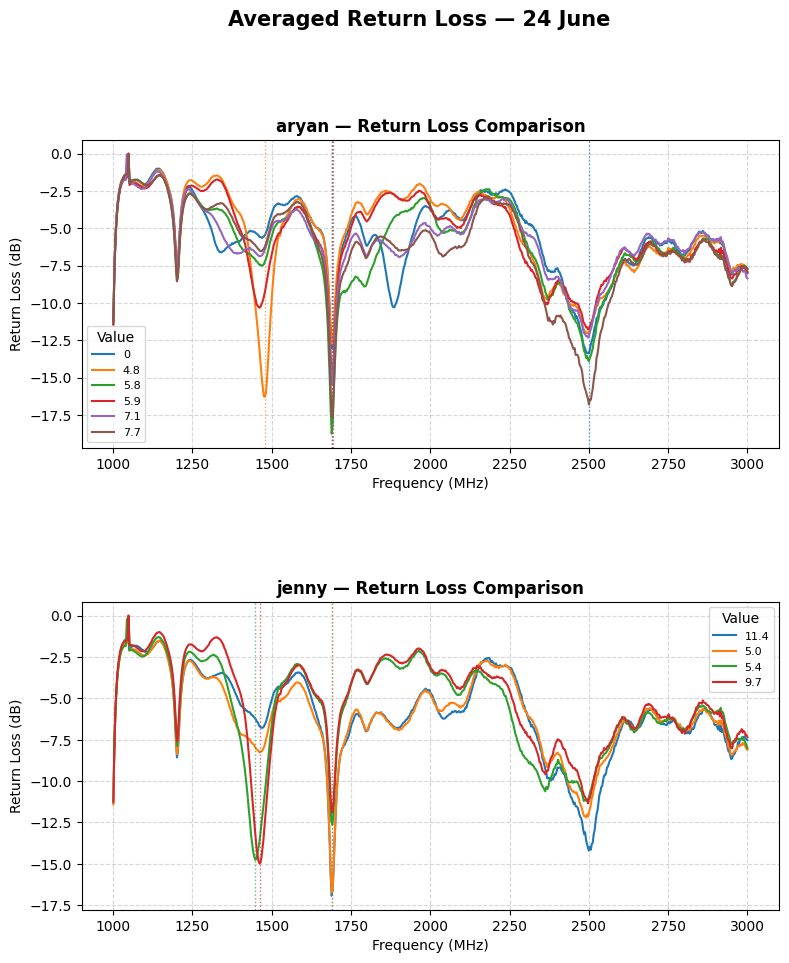

Plot saved to return_loss_summary.png


In [8]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

DIR = '/Users/jenny/Documents/Github/glucoring/' + 'src/data/everything/'
COLS = ['Frequency(Hz)', 'Return Loss(dB)']

FREQ_MIN_MHZ = 1000
FREQ_MAX_MHZ = 3000

# ── 1. Load data ──────────────────────────────────────────────────────────────
data = {}
for folder in os.listdir(DIR):
    if folder.startswith('.'):
        continue
    folder_path = os.path.join(DIR, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith('.csv'):
                file_path = os.path.join(folder_path, file)
                data[folder + '_' + file] = pd.read_csv(file_path)

# ── 2. Average 3 files per folder ─────────────────────────────────────────────
folders = sorted({key.split('_')[0] for key in data})
averaged = {}

for folder in folders:
    group = [df[COLS] for key, df in data.items() if key.startswith(folder + '_')]
    if len(group) != 3:
        print(f"⚠️  '{folder}' has {len(group)} file(s), expected 3 — skipping.")
        continue
    averaged[folder] = pd.concat(group).groupby(level=0).mean().reset_index(drop=True)
    averaged[folder]['Frequency(Hz)'] = group[0]['Frequency(Hz)'].values

# ── 3. Filter frequency range ─────────────────────────────────────────────────
for folder in averaged:
    df   = averaged[folder]
    mask = (df['Frequency(Hz)'] / 1e6 >= FREQ_MIN_MHZ) & \
           (df['Frequency(Hz)'] / 1e6 <= FREQ_MAX_MHZ)
    averaged[folder] = df[mask].reset_index(drop=True)

# ── 4. Group folders by base name (strip trailing digits + decimals) ───────────
groups = {}
for folder in averaged:
    base = re.sub(r'[\s_-]*[\d.]+$', '', folder)  # 'jenny-8.5' → 'jenny'
    groups.setdefault(base, []).append(folder)

# ── 5. Statistics ─────────────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print(f"{'FOLDER':<20} {'RL Min':>9} {'RL Max':>9} {'RL Mean':>9} {'RL Std':>9} {'Min @ (MHz)':>12}")
print(f"{'─'*70}")

for folder, df in averaged.items():
    rl       = df['Return Loss(dB)']
    freq_mhz = df['Frequency(Hz)'] / 1e6
    min_idx  = rl.idxmin()
    print(f"{folder:<20} {rl.min():>9.2f} {rl.max():>9.2f} {rl.mean():>9.2f} {rl.std():>9.2f} {freq_mhz[min_idx]:>12.2f}")

print(f"{'─'*70}\n")

# ── 6. Plot — one subplot per base group, all variants overlaid ───────────────
n      = len(groups)
fig    = plt.figure(figsize=(9, 5 * n))
gs     = gridspec.GridSpec(n, 1, figure=fig, hspace=0.5)
colors = plt.cm.tab10.colors

for i, (base, members) in enumerate(sorted(groups.items())):
    ax = fig.add_subplot(gs[i, 0])

    for j, folder in enumerate(sorted(members)):
        df       = averaged[folder]
        freq_mhz = df['Frequency(Hz)'] / 1e6
        rl       = df['Return Loss(dB)']
        color    = colors[j % len(colors)]
        min_idx  = rl.idxmin()
        label    = re.search(r'[\d.]+$', folder).group()

        ax.plot(freq_mhz, rl, color=color, linewidth=1.5, label=label)
        ax.axvline(freq_mhz[min_idx], color=color, linestyle=':', linewidth=1.0,
                   alpha=0.7)

    ax.set_title(f'{base} — Return Loss Comparison', fontweight='bold')
    ax.set_xlabel('Frequency (MHz)')
    ax.set_ylabel('Return Loss (dB)')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title='Value', fontsize=8)

plt.suptitle('Averaged Return Loss — 24 June', fontsize=15, fontweight='bold', y=1.01)
plt.savefig(os.path.join(DIR, 'return_loss_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to return_loss_summary.png")


──────────────────────────────────────────────────────────────────────
FOLDER                  RL Min    RL Max   RL Mean    RL Std  Min @ (MHz)
──────────────────────────────────────────────────────────────────────
jenny-8.51              -15.71      0.00     -5.97      2.44      1689.06
jenny-8.52              -20.97     -0.05     -5.48      3.32      1461.70
──────────────────────────────────────────────────────────────────────



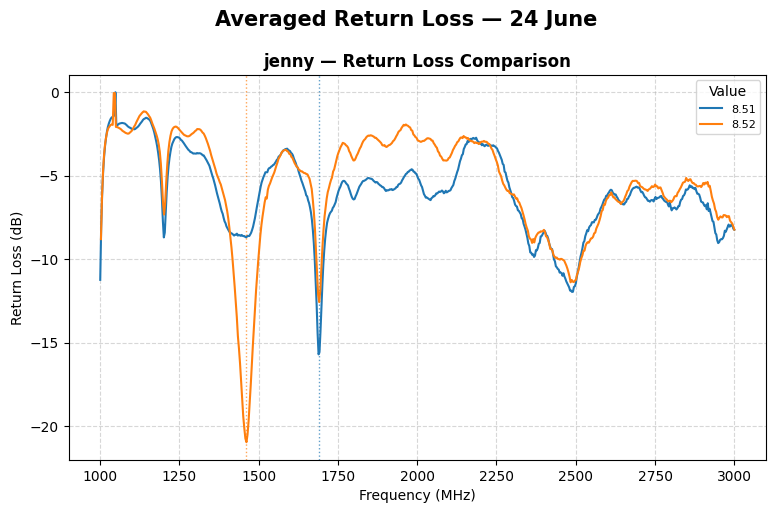

Plot saved to return_loss_summary.png


In [9]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

DIR = '/Users/jenny/Documents/Github/glucoring/' + 'src/data/everything/jenny-8.5'
COLS = ['Frequency(Hz)', 'Return Loss(dB)']

FREQ_MIN_MHZ = 1000
FREQ_MAX_MHZ = 3000

# ── 1. Load data ──────────────────────────────────────────────────────────────
data = {}
for folder in os.listdir(DIR):
    if folder.startswith('.'):
        continue
    folder_path = os.path.join(DIR, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith('.csv'):
                file_path = os.path.join(folder_path, file)
                data[folder + '_' + file] = pd.read_csv(file_path)

# ── 2. Average 3 files per folder ─────────────────────────────────────────────
folders = sorted({key.split('_')[0] for key in data})
averaged = {}

for folder in folders:
    group = [df[COLS] for key, df in data.items() if key.startswith(folder + '_')]
    if len(group) != 3:
        print(f"⚠️  '{folder}' has {len(group)} file(s), expected 3 — skipping.")
        continue
    averaged[folder] = pd.concat(group).groupby(level=0).mean().reset_index(drop=True)
    averaged[folder]['Frequency(Hz)'] = group[0]['Frequency(Hz)'].values

# ── 3. Filter frequency range ─────────────────────────────────────────────────
for folder in averaged:
    df   = averaged[folder]
    mask = (df['Frequency(Hz)'] / 1e6 >= FREQ_MIN_MHZ) & \
           (df['Frequency(Hz)'] / 1e6 <= FREQ_MAX_MHZ)
    averaged[folder] = df[mask].reset_index(drop=True)

# ── 4. Group folders by base name (strip trailing digits + decimals) ───────────
groups = {}
for folder in averaged:
    base = re.sub(r'[\s_-]*[\d.]+$', '', folder)  # 'jenny-8.5' → 'jenny'
    groups.setdefault(base, []).append(folder)

# ── 5. Statistics ─────────────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print(f"{'FOLDER':<20} {'RL Min':>9} {'RL Max':>9} {'RL Mean':>9} {'RL Std':>9} {'Min @ (MHz)':>12}")
print(f"{'─'*70}")

for folder, df in averaged.items():
    rl       = df['Return Loss(dB)']
    freq_mhz = df['Frequency(Hz)'] / 1e6
    min_idx  = rl.idxmin()
    print(f"{folder:<20} {rl.min():>9.2f} {rl.max():>9.2f} {rl.mean():>9.2f} {rl.std():>9.2f} {freq_mhz[min_idx]:>12.2f}")

print(f"{'─'*70}\n")

# ── 6. Plot — one subplot per base group, all variants overlaid ───────────────
n      = len(groups)
fig    = plt.figure(figsize=(9, 5 * n))
gs     = gridspec.GridSpec(n, 1, figure=fig, hspace=0.5)
colors = plt.cm.tab10.colors

for i, (base, members) in enumerate(sorted(groups.items())):
    ax = fig.add_subplot(gs[i, 0])

    for j, folder in enumerate(sorted(members)):
        df       = averaged[folder]
        freq_mhz = df['Frequency(Hz)'] / 1e6
        rl       = df['Return Loss(dB)']
        color    = colors[j % len(colors)]
        min_idx  = rl.idxmin()
        label    = re.search(r'[\d.]+$', folder).group()

        ax.plot(freq_mhz, rl, color=color, linewidth=1.5, label=label)
        ax.axvline(freq_mhz[min_idx], color=color, linestyle=':', linewidth=1.0,
                   alpha=0.7)

    ax.set_title(f'{base} — Return Loss Comparison', fontweight='bold')
    ax.set_xlabel('Frequency (MHz)')
    ax.set_ylabel('Return Loss (dB)')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title='Value', fontsize=8)

plt.suptitle('Averaged Return Loss — 24 June', fontsize=15, fontweight='bold', y=1.01)
plt.savefig(os.path.join(DIR, 'return_loss_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to return_loss_summary.png")